In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as scp
import numpy as np

from scipy.stats import median_abs_deviation
from os import makedirs
from os.path import isfile

# Define pipeline functions 

In [2]:
def dimensions_sparsity_check(expression_matrix_df: pd.DataFrame,
                              sample: str) -> None:
    no_genes, no_cells = expression_matrix_df.shape[0], expression_matrix_df.shape[1]
    
    print(f"For dataset {sample}")
    print(f"\t\u00b7# genes: {no_genes}")
    print(f"\t\u00b7# cells: {no_cells}")

    sparsity_coeff = round((expression_matrix_df == 0).sum().sum()/(no_genes*no_cells),2)*100

    print(f"\nSparsity coefficient: {sparsity_coeff}%")

def total_zeroes_filtering(expression_matrix_df: pd.DataFrame) -> pd.DataFrame:
    print(f"Number of genes with zero total expression: {(expression_matrix_df.sum(axis=1) == 0).sum()}")
    print(f"Number of cells consisting of non-expressed genes : {(expression_matrix_df.sum() == 0).sum()}")

    expression_matrix_df = expression_matrix_df.loc[expression_matrix_df.sum(axis=1) != 0] 
    expression_matrix_df = expression_matrix_df.loc[:,expression_matrix_df.sum(axis=0) != 0]

    return expression_matrix_df


def specific_type_RNA_filtering(expression_matrix_df: pd.DataFrame,
                                st_RNA_label: str,
                                st_ensgid: pd.Series,
                                st_RNA_threshold: float,
                                figure_output_file: str,
                                save_fig: bool = False) -> pd.DataFrame:
    if not st_RNA_label in ["mt_RNA","rRNA","apopt_RNA"]:
        raise ValueError("st_RNA_label can be assigned:'mt_RNA','rRNA' or 'apopt_RNA'")

    no_detected_st_genes = (expression_matrix_df.index.isin(st_ensgid)).sum()
    print(f"Number of detected {st_RNA_label} genes in data: {no_detected_st_genes}")

    if no_detected_st_genes == 0: return expression_matrix_df

    st_RNA_cell_percentage = expression_matrix_df.loc[expression_matrix_df.index.isin(st_ensgid)].sum()/expression_matrix_df.sum()

    st_RNA_cell_percentage.hist(bins=20,grid=False)

    plt.vlines(st_RNA_threshold,0,1500,colors="red",linestyles="dashed");

    plt.title(f"Percentile of {st_RNA_label} wrt cell total expression");
    plt.xlabel(f"{st_RNA_label} relative expression (%)");

    plt.yscale("log");

    if save_fig: plt.savefig(f"{figure_output_file}/{st_RNA_label}_filtering.png")
    
    print(f"Number of cells with excess of {st_RNA_label}: {(st_RNA_cell_percentage > st_RNA_threshold).sum()}")
    expression_matrix_df = expression_matrix_df.loc[:,st_RNA_cell_percentage <= st_RNA_threshold]

    return expression_matrix_df


def non_zero_cells(expression_matrix_df: pd.DataFrame,
                   non_zero_cells_threshold: int,
                   vline_lim: int,
                   figure_output_file: str,
                   save_fig: bool = False) -> pd.DataFrame:
    non_zero_cells_ser = expression_matrix_df.astype(bool).sum(axis=1)

    np.log10(non_zero_cells_ser).hist(bins=25,
                              grid=False);

    plt.vlines(np.log10(non_zero_cells_threshold),0,vline_lim,color="red",linestyles="dashed");

    plt.xlabel("$log_{10}(\\# non-zero\\ cells)$");

    if save_fig: plt.savefig(f"{figure_output_file}/non_zero_cells_filtering.png");

    print(f"Genes to be filtered out: {(non_zero_cells_ser <= non_zero_cells_threshold).sum()}");
    expression_matrix_df = expression_matrix_df.loc[non_zero_cells_ser > non_zero_cells_threshold]

    return expression_matrix_df


def logCPM_transform(expression_matrix_df: pd.DataFrame,
                     transformation: str) -> pd.DataFrame:
    if not transformation in ["log","CPM","logCPM"]:
        raise ValueError("trasformation can be assigned:'log','CPM','logCPM'")
    
    match transformation:
        case "log":
            return np.log10(1+expression_matrix_df)
        case "CPM":
            return expression_matrix_df/expression_matrix_df.sum()*1e6
        case "logCPM":
            return np.log10(1+(expression_matrix_df/expression_matrix_df.sum()*1e6))
        
        
def doublets_empty_droplets_MAD(expression_matrix_df: pd.DataFrame,
                                vline_log_lim: int,
                                vline_lim: int,
                                figure_output_file: str,
                                save_fig: bool = False) -> tuple[int,int]:
    count_depth_ser = expression_matrix_df.sum()
    
    count_depth_median = count_depth_ser.median()
    MAD = median_abs_deviation(count_depth_ser)

    lower_MAD = count_depth_median - 3*MAD
    upper_MAD = count_depth_median + 3*MAD

    print(f"Lower MAD threshold: {lower_MAD}")
    print(f"Upper MAD threshold: {upper_MAD}")

    print(f"Cells count depth below lower MAD threshold: {(count_depth_ser < lower_MAD).sum()}")
    print(f"Cells count depth above upper MAD threshold: {(count_depth_ser > upper_MAD).sum()}")

    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,6))
    
    np.log10(count_depth_ser).hist(bins=30,grid=False,ax=ax1)

    ax1.vlines(np.log10(lower_MAD),0,vline_log_lim,color="red",linestyles="dashed")
    ax1.vlines(np.log10(upper_MAD),0,vline_log_lim,color="red",linestyles="dashed")

    ax1.set_xlabel("$log_{10}(count\\ depth)$")


    count_depth_ser.hist(bins=30,grid=False,ax=ax2)

    ax2.vlines(lower_MAD,0,vline_lim,color="red",linestyles="dashed")
    ax2.vlines(upper_MAD,0,vline_lim,color="red",linestyles="dashed")

    ax2.set_xlabel("count depth")
    
    if save_fig: fig.savefig(f"{figure_output_file}/MAD_log_non_corrected.png")

    return lower_MAD,upper_MAD


def call_scrublet(expression_matrix_df:pd.DataFrame) -> dict:
    adata_obj = scp.AnnData(expression_matrix_df.T)
    scrublet_doublets = {}

    for random_state in [0,42]:
        scp.pp.scrublet(adata_obj,
                        random_state=random_state)
        
        scrublet_doublets[random_state] = adata_obj.obs["predicted_doublet"][adata_obj.obs["predicted_doublet"] == True].index
    
    return scrublet_doublets

In [ ]:
parameters_dict = {"set_1":
                   {
                     "mt_RNA_threshold": 0.1,
                     "rRNA_threshold": 0.1,
                     "apoptosis_threshold": 0.1,
                     "non_zero_cells_threshold": 5
                   },
                   "set_2":
                   {
                     "mt_RNA_threshold": 0.05,
                     "rRNA_threshold": 0.05,
                     "apoptosis_threshold": 0.05,
                     "non_zero_cells_threshold": 3  
                   },
                   "set_3":{
                     "mt_RNA_threshold": 0.15,
                     "rRNA_threshold": 0.15,
                     "apoptosis_threshold": 0.15,
                     "non_zero_cells_threshold": 10 
                   }}

In [4]:
output_dir = "."

session_dir = f"{output_dir}/session_a"
makedirs(session_dir,exist_ok=True)

In [5]:
sample = "pbmc.bead.enriched.sample.zheng"

data_file = f"./pbmc.csv.gz"
utility_file = f"./annotation.csv.gz"

In [6]:
set_choice = "set_1"

In [7]:
figure_output_dir = f"{session_dir}/figures"
HVGs_output_dir = f"{session_dir}/HVGs"
processed_data_output_dir = f"{session_dir}/processed_data"


for set_choice_key in parameters_dict.keys():
    makedirs(f"{figure_output_dir}/{set_choice_key}",exist_ok=True)
    makedirs(f"{HVGs_output_dir}/{set_choice_key}",exist_ok=True)
    makedirs(f"{processed_data_output_dir}/{set_choice_key}",exist_ok=True)

In [8]:
expression_matrix_df = pd.read_csv(data_file,index_col=0)
ensembl_df = pd.read_csv(utility_file,index_col=0)

In [9]:
expression_matrix_df.head(15)

,CGTGATGATTTCAC_1_b_cells,TTTGACTGTTGAGC_1_cd34_filtered,GACAGTACCTGTGA_1_memory_t,CAGACCCTATTCCT_1_b_cells,CAGCTAGATGACTG_1_cd4_t_helper,ACAGTTCTATTGGC_1_naive_cytotoxic,ACGACAACTAAGCC_1_b_cells,CCATTAACCCTAAG_1_cd4_t_helper,TCAATCACCGTCTC_1_cd56_nk,ATTACCACGGTGGA_1_cd56_nk,...,TGGATGTGCGAGTT_1_cd56_nk,GAGGGCCTCCTCCA_1_b_cells,AGGGTTTGATCACG_1_naive_t,TCAACACTTAACGC_1_cd4_t_helper,GTCCCATGTGACAC_1_cd34_filtered,ATGGTGACTGTCCC_1_cd34_filtered,GCCCAGGAACACTG_1_b_cells,ATATGAACATGACC_1_cd4_t_helper,AGACTTCTGGTTTG_1_b_cells,AGCTGTGATTGTGG_1_naive_cytotoxic
ENSG00000237683,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000230021,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000228327,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237491,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000225880,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
ENSG00000230368,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000187634,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000188976,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000187961,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000187583,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
ensembl_df.head(15)

,ensgid,gene_biotype,TF_status,APOPT_status,RB_status,MT_status,HGNC_id,gene_symbol,gene_alias,gene_prev_symbol
0,ENSG00000000003,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:11858,TSPAN6,T245|TSPAN-6,TM4SF6
1,ENSG00000000005,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:17757,TNMD,myodulin|ChM1L|tendin|TEM|BRICD4,NO_PREV_SYMBOL
2,ENSG00000000419,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:3005,DPM1,MPDS|CDGIE,NO_PREV_SYMBOL
3,ENSG00000000457,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:19285,SCYL3,PACE-1|PACE1,NO_PREV_SYMBOL
4,ENSG00000000460,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:25565,FIRRM,FLJ10706|Apolo1|FLIP|MEICA1,C1orf112
5,ENSG00000000938,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:3697,FGR,c-fgr|p55c-fgr,SRC2
6,ENSG00000000971,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:4883,CFH,HUS|FHL1|ARMS1|ARMD4,HF|HF1|HF2
7,ENSG00000001036,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:4008,FUCA2,MGC1314|dJ20N2.5,NO_PREV_SYMBOL
8,ENSG00000001084,protein_coding,NO_TF,NO_APOPT,NO_RB,NO_MT,HGNC:4311,GCLC,GCS,GLCLC|GLCL
9,ENSG00000001167,protein_coding,NFYA,NO_APOPT,NO_RB,NO_MT,HGNC:7804,NFYA,HAP2|CBF-B|NF-YA,NO_PREV_SYMBOL


# Function-type pipeline

In [11]:
dimensions_sparsity_check(expression_matrix_df,sample)

For dataset pbmc.bead.enriched.sample.zheng
	·# genes: 16791
	·# cells: 3774

Sparsity coefficient: 96.0%


In [12]:
expression_matrix_df = total_zeroes_filtering(expression_matrix_df)

Number of genes with zero total expression: 0
Number of cells consisting of non-expressed genes : 0


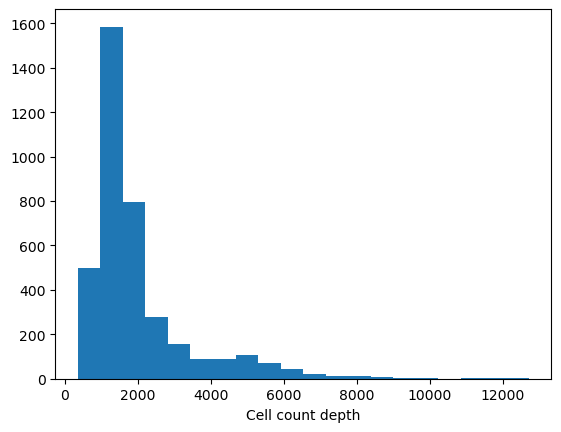

In [13]:
expression_matrix_df.sum().hist(bins=20,
                                grid=False);

plt.xlabel("Cell count depth");

if not isfile(f"{figure_output_dir}/cell_count_depth.png"): plt.savefig(f"{figure_output_dir}/cell_count_depth.png");

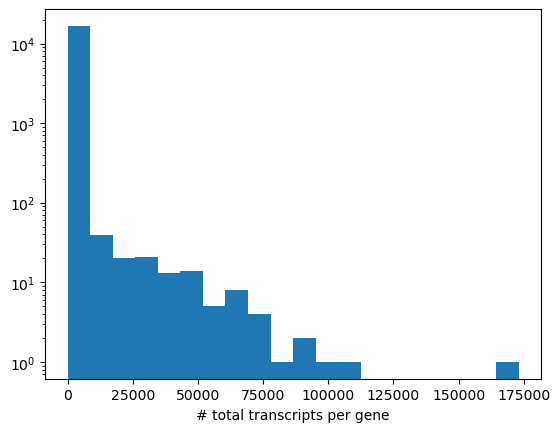

In [14]:
expression_matrix_df.sum(axis=1).hist(bins=20,
                                grid=False);

plt.yscale("log");

plt.xlabel("# total transcripts per gene");

if not isfile(f"{figure_output_dir}/total_transcripts_per_cell.png"): plt.savefig(f"{figure_output_dir}/total_transcripts_per_cell.png")

In [15]:
mitochondrial_ensgid = ensembl_df.loc[ensembl_df.MT_status != "NO_MT"].ensgid
apoptosis_ensgid = ensembl_df.loc[ensembl_df.APOPT_status != "NO_APOPT"].ensgid
ribosomal_ensgid = ensembl_df.loc[ensembl_df.RB_status != "NO_RB"].ensgid

Number of detected mt_RNA genes in data: 13
Number of cells with excess of mt_RNA: 6


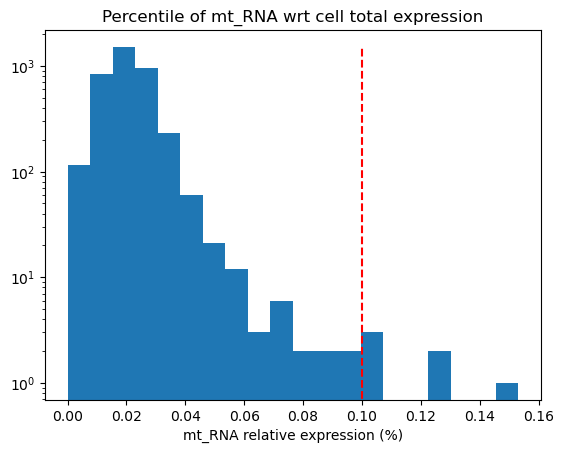

In [16]:
mt_RNA_threshold = parameters_dict[set_choice]["mt_RNA_threshold"]

expression_matrix_df = specific_type_RNA_filtering(expression_matrix_df,
                                                   "mt_RNA",
                                                   mitochondrial_ensgid,
                                                   mt_RNA_threshold,
                                                   f"{figure_output_dir}/{set_choice}",
                                                   save_fig=True)

In [17]:
expression_matrix_df = total_zeroes_filtering(expression_matrix_df)

Number of genes with zero total expression: 3
Number of cells consisting of non-expressed genes : 0


In [18]:
rRNA_threshold = parameters_dict[set_choice]["rRNA_threshold"]

expression_matrix_df = specific_type_RNA_filtering(expression_matrix_df,
                                                   "rRNA",
                                                   ribosomal_ensgid,
                                                   rRNA_threshold,
                                                   f"{figure_output_dir}/{set_choice}")

Number of detected rRNA genes in data: 0


Number of detected apopt_RNA genes in data: 149
Number of cells with excess of apopt_RNA: 0


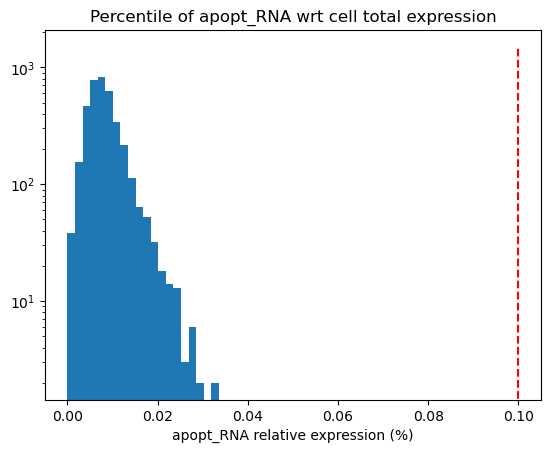

In [19]:
apoptosis_threshold = parameters_dict[set_choice]["apoptosis_threshold"]

expression_matrix_df = specific_type_RNA_filtering(expression_matrix_df,
                                                   "apopt_RNA",
                                                   apoptosis_ensgid,
                                                   apoptosis_threshold,
                                                   f"{figure_output_dir}/{set_choice}",
                                                   save_fig=True)

In [20]:
expression_matrix_df = total_zeroes_filtering(expression_matrix_df)

Number of genes with zero total expression: 0
Number of cells consisting of non-expressed genes : 0


Lower MAD threshold: 262.0
Upper MAD threshold: 2764.0
Cells count depth below lower MAD threshold: 0
Cells count depth above upper MAD threshold: 637


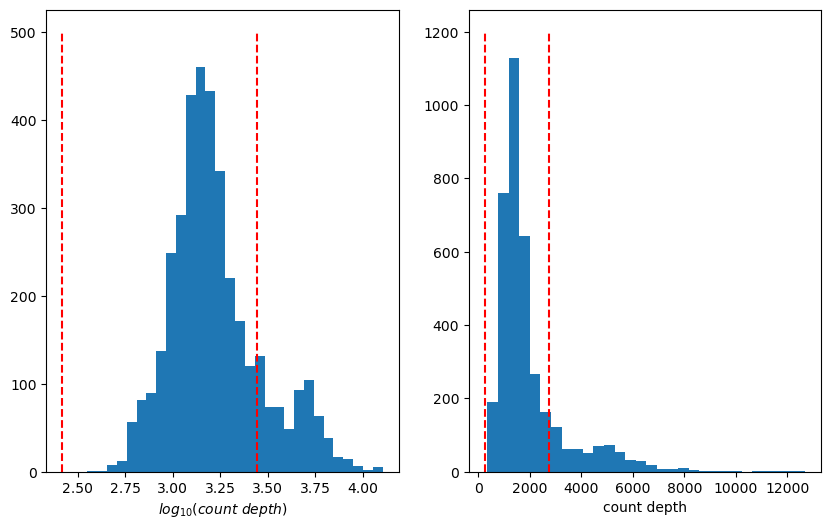

In [21]:
lower_MAD,upper_MAD = doublets_empty_droplets_MAD(expression_matrix_df,
                                                  500,
                                                  1200,
                                                  figure_output_dir)

In [22]:
count_depth_ser = expression_matrix_df.sum()

high_cd_comp_index = count_depth_ser[count_depth_ser >= 3800].index
high_expression_matrix_df = expression_matrix_df.loc[:,high_cd_comp_index]

Lower MAD threshold: 3260.0
Upper MAD threshold: 7124.0
Cells count depth below lower MAD threshold: 0
Cells count depth above upper MAD threshold: 42


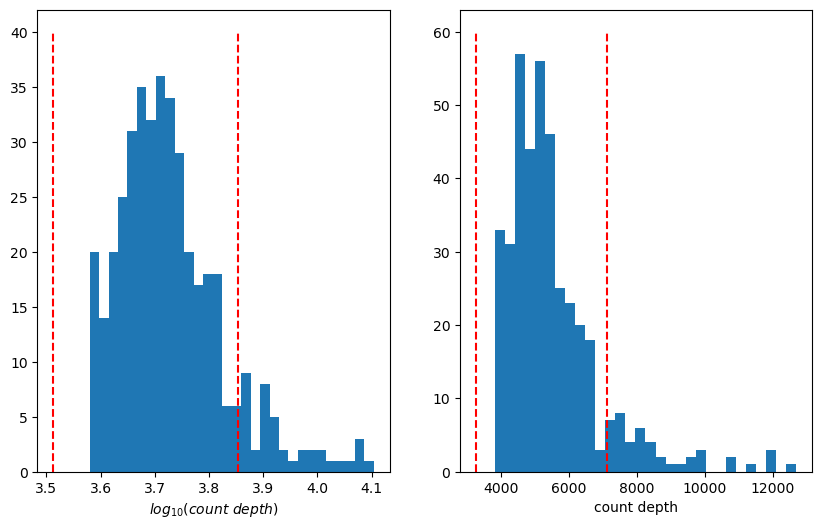

In [23]:
_,upper_high_cd_MAD = doublets_empty_droplets_MAD(high_expression_matrix_df,
                                                  40,
                                                  60,
                                                  f"{figure_output_dir}/{set_choice}")

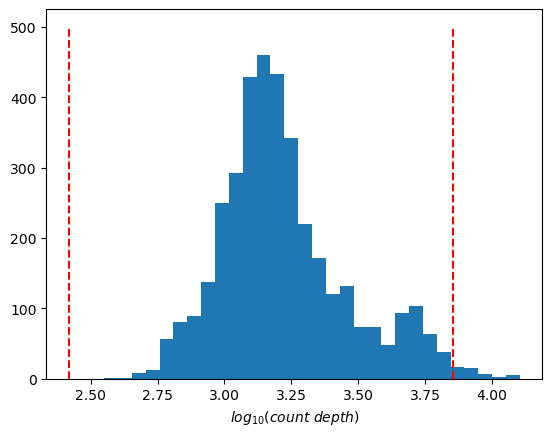

In [24]:
np.log10(count_depth_ser).hist(bins=30,
                 grid=False);

plt.vlines(np.log10(lower_MAD),0,500,color="red",linestyles="dashed");
plt.vlines(np.log10(upper_high_cd_MAD),0,500,color="red",linestyles="dashed");

plt.xlabel("$log_{10}(count\\ depth)$");

if not isfile(f"{figure_output_dir}/{set_choice}/MAD_log_corrected.png"):
    plt.savefig(f"{figure_output_dir}/{set_choice}/MAD_log_corrected.png")

In [25]:
scrublet_doublets_dict = call_scrublet(expression_matrix_df)

In [26]:
scrublet_doublets_dict[0]

Index(['GGCTAAACGTCCTC_1_naive_cytotoxic', 'TATACCACTTTGCT_1_cd34_filtered',
       'TTAGCTACAGTTCG_1_cd56_nk', 'ATCATCTGGACGAG_1_cd34_filtered',
       'TATCTTCTCAGAGG_1_cytotoxic_t', 'TACGTACTAGCACT_1_cd56_nk',
       'TGACTTACCTTATC_1_cd34_filtered', 'CGCCGAGAACGGAG_1_cytotoxic_t',
       'AAGGTCTGCATGAC_1_cytotoxic_t'],
      dtype='str')

In [27]:
count_depth_ser.loc[scrublet_doublets_dict[0]]

GGCTAAACGTCCTC_1_naive_cytotoxic    2241
TATACCACTTTGCT_1_cd34_filtered      6648
TTAGCTACAGTTCG_1_cd56_nk            1342
ATCATCTGGACGAG_1_cd34_filtered      2881
TATCTTCTCAGAGG_1_cytotoxic_t        1442
TACGTACTAGCACT_1_cd56_nk            1343
TGACTTACCTTATC_1_cd34_filtered      7567
CGCCGAGAACGGAG_1_cytotoxic_t         951
AAGGTCTGCATGAC_1_cytotoxic_t        2594
dtype: int64

In [28]:
scrublet_doublets_dict[42]

Index(['TTAGCTACAGTTCG_1_cd56_nk', 'TGACTTACCTTATC_1_cd34_filtered',
       'CGCCGAGAACGGAG_1_cytotoxic_t', 'AAGGTCTGCATGAC_1_cytotoxic_t'],
      dtype='str')

In [29]:
count_depth_ser.loc[scrublet_doublets_dict[42]]

TTAGCTACAGTTCG_1_cd56_nk          1342
TGACTTACCTTATC_1_cd34_filtered    7567
CGCCGAGAACGGAG_1_cytotoxic_t       951
AAGGTCTGCATGAC_1_cytotoxic_t      2594
dtype: int64

In [30]:
expression_matrix_df = expression_matrix_df.loc[:,(count_depth_ser >= lower_MAD) & (count_depth_ser <= upper_high_cd_MAD)]

In [31]:
expression_matrix_df = total_zeroes_filtering(expression_matrix_df)

Number of genes with zero total expression: 124
Number of cells consisting of non-expressed genes : 0


Genes to be filtered out: 4105


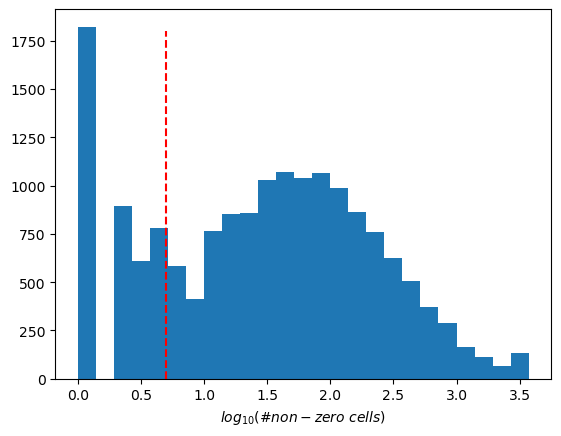

In [32]:
non_zero_cells_threshold = parameters_dict[set_choice]["non_zero_cells_threshold"]

aux_expression_matrix_df = non_zero_cells(expression_matrix_df,
                                      non_zero_cells_threshold,
                                      1800,
                                      f"{figure_output_dir}/{set_choice}",
                                      save_fig=True)

In [33]:
expression_matrix_df = aux_expression_matrix_df

In [34]:
expression_matrix_df = total_zeroes_filtering(expression_matrix_df)

Number of genes with zero total expression: 0
Number of cells consisting of non-expressed genes : 0


In [35]:
log_cpm_expression_matrix_df = logCPM_transform(expression_matrix_df,
                                             "logCPM")

In [36]:
log_cpm_expression_matrix_df

,CGTGATGATTTCAC_1_b_cells,GACAGTACCTGTGA_1_memory_t,CAGACCCTATTCCT_1_b_cells,CAGCTAGATGACTG_1_cd4_t_helper,ACAGTTCTATTGGC_1_naive_cytotoxic,ACGACAACTAAGCC_1_b_cells,CCATTAACCCTAAG_1_cd4_t_helper,TCAATCACCGTCTC_1_cd56_nk,ATTACCACGGTGGA_1_cd56_nk,GTATCACTCTGAGT_1_cd56_nk,...,TGGATGTGCGAGTT_1_cd56_nk,GAGGGCCTCCTCCA_1_b_cells,AGGGTTTGATCACG_1_naive_t,TCAACACTTAACGC_1_cd4_t_helper,GTCCCATGTGACAC_1_cd34_filtered,ATGGTGACTGTCCC_1_cd34_filtered,GCCCAGGAACACTG_1_b_cells,ATATGAACATGACC_1_cd4_t_helper,AGACTTCTGGTTTG_1_b_cells,AGCTGTGATTGTGG_1_naive_cytotoxic
ENSG00000237683,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
ENSG00000228327,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
ENSG00000237491,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
ENSG00000225880,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,2.786927
ENSG00000188976,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695,0.000000,3.032388,0.000000,2.955550,0.000000,0.000000,0.000000,2.650530,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
ENSG00000198727,3.594545,0.000000,3.400653,3.256339,3.631629,3.544898,3.349563,3.348723,3.539228,3.11469,...,3.488258,3.459821,2.93642,0.000000,3.129042,3.14905,3.102716,3.486924,0.0,3.087602
ENSG00000220023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000
ENSG00000215700,0.000000,0.000000,2.923877,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,2.987189,0.000000,0.00000,0.000000,0.000000,0.0,0.000000


In [37]:
dimensions_sparsity_check(expression_matrix_df,sample)

For dataset pbmc.bead.enriched.sample.zheng
	·# genes: 12559
	·# cells: 3726

Sparsity coefficient: 94.0%


In [38]:
expression_matrix_df.to_csv(f"{processed_data_output_dir}/{set_choice}/filtered.raw.csv.gz",compression="gzip")
log_cpm_expression_matrix_df.to_csv(f"{processed_data_output_dir}/{set_choice}/filtered.logCPM.csv.gz",compression="gzip")

# HVGs

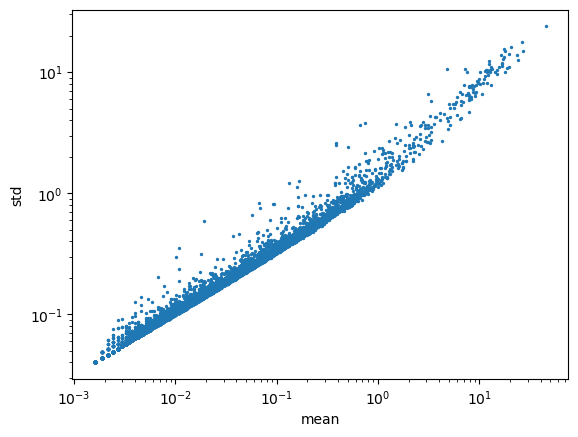

In [39]:
plt.scatter(expression_matrix_df.mean(axis=1), y=expression_matrix_df.std(axis=1),s=2);

plt.xscale("log");
plt.yscale("log");

plt.xlabel("mean");
plt.ylabel("std");

In [40]:
adata_obj = scp.AnnData(X=expression_matrix_df.T)

In [41]:
adata_obj.layers["logCPM"] = log_cpm_expression_matrix_df.T

In [42]:
scp.pp.highly_variable_genes(adata_obj,
                             layer="logCPM",
                             flavor="seurat")

In [43]:
Seurat_mvp_HVGs_index = adata_obj.var['highly_variable'][adata_obj.var['highly_variable'] == True].index

In [44]:
with open(f"{HVGs_output_dir}/{set_choice}/Seurat_mvp_HVGs.txt","w") as OUT:
    for nid,gene in enumerate(Seurat_mvp_HVGs_index):
        OUT.write(f"{nid}.{gene}\n")

In [45]:
Seurat_mvp_HVGs_index

Index(['ENSG00000237683', 'ENSG00000225880', 'ENSG00000187961',
       'ENSG00000187583', 'ENSG00000188290', 'ENSG00000131591',
       'ENSG00000186891', 'ENSG00000186827', 'ENSG00000176022',
       'ENSG00000107404',
       ...
       'ENSG00000160223', 'ENSG00000141959', 'ENSG00000142185',
       'ENSG00000160255', 'ENSG00000227039', 'ENSG00000197381',
       'ENSG00000173638', 'ENSG00000142173', 'ENSG00000160285',
       'ENSG00000160307'],
      dtype='str', length=3167)

In [46]:
scp.pp.highly_variable_genes(adata_obj,
                             flavor="seurat_v3")

In [47]:
Seurat_vst_HVGs_index = adata_obj.var['highly_variable'][adata_obj.var['highly_variable'] == True].index

In [48]:
Seurat_vst_HVGs_index

Index(['ENSG00000188290', 'ENSG00000187608', 'ENSG00000186891',
       'ENSG00000186827', 'ENSG00000162576', 'ENSG00000215014',
       'ENSG00000228594', 'ENSG00000008130', 'ENSG00000116151',
       'ENSG00000116213',
       ...
       'ENSG00000182240', 'ENSG00000160185', 'ENSG00000184441',
       'ENSG00000183255', 'ENSG00000160298', 'ENSG00000160307',
       'ENSG00000198712', 'ENSG00000198899', 'ENSG00000198840',
       'ENSG00000198886'],
      dtype='str', length=2000)

In [49]:
with open(f"{HVGs_output_dir}/{set_choice}/Seurat_vst_HVGs.txt","w") as OUT:
    for nid,gene in enumerate(Seurat_vst_HVGs_index):
        OUT.write(f"{nid}.{gene}\n")